# Predição de falha de disco a partir de telemetria SMART

**UNIVESP — PJI410 · Projeto Integrador em Computação IV**
Projeto: Bancada de Validação Física e Inventário Preditivo

---

## Objetivo

Treinar e avaliar um modelo capaz de responder a uma pergunta operacional concreta:

> Dado o estado atual de um disco rígido, qual a probabilidade de ele falhar nos próximos 30 dias?

Esse número é o que a bancada calcula quando um computador da rede escolar é conectado, e é o que o aplicativo mostra ao gestor para priorizar a troca de peças **antes** do laboratório parar.

## Como este notebook atende ao tema da disciplina

| Exigência do PJI410 | Onde está |
|---|---|
| Análise de dados **em escala** | 584 mil registros diários de telemetria, 5.000 discos |
| **Aprendizagem de máquina** | Classificação supervisionada, 4 modelos comparados |
| Dados **capturados por IoT** | A bancada lê o SMART real via `smartctl` e aplica este modelo |
| **Interface de visualização** | Aplicativo Flutter consumindo o resultado pelo Firestore |

## Aviso sobre a origem dos dados

Os dados usados aqui são **sintéticos**, gerados por `gerar_dataset.py`. O esquema é idêntico ao do *Backblaze Hard Drive Test Data*, o conjunto público de referência na área. A seção final explica como substituir por dados reais sem alterar uma linha do código de modelagem.

Esse aviso precisa constar também no relatório final: um modelo treinado em dados simulados aprendeu apenas os padrões que o gerador inseriu.

## 1. Preparação do ambiente

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold,
                                     cross_val_score)
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve,
                             ConfusionMatrixDisplay)
import joblib

warnings.filterwarnings("ignore")

RAIZ = os.getcwd()
DADOS = os.path.join(RAIZ, "data", "smart_telemetria.csv.gz")
FIGURAS = os.path.join(RAIZ, "figuras")
MODELO = os.path.join(RAIZ, "modelo")
os.makedirs(FIGURAS, exist_ok=True)
os.makedirs(MODELO, exist_ok=True)

HORIZONTE = 30   # dias de antecedência que queremos prever
SEMENTE = 42     # fixa para que os resultados sejam reproduzíveis

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

COR = {"ok": "#2E9E5B", "atencao": "#E0A008", "critico": "#D64545",
       "azul": "#2F6FD0", "cinza": "#8A8F98"}

print("Ambiente pronto.")

Ambiente pronto.


## 2. Carregamento dos dados

Cada linha é uma leitura diária de um disco. A coluna `failure` vale 1 apenas no dia em que o disco falhou — em todos os outros dias vale 0.

In [2]:
df = pd.read_csv(DADOS)
df["date"] = pd.to_datetime(df["date"])

print(f"{len(df):,} linhas x {df.shape[1]} colunas")
print(f"{df['serial_number'].nunique():,} discos distintos")
print(f"Janela: {df['date'].min().date()} a {df['date'].max().date()}")
df.head()

584,443 linhas x 15 colunas
5,000 discos distintos
Janela: 2026-05-24 a 2026-09-20


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_12_raw,smart_187_raw,smart_188_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_241_raw
0,2026-05-24,SWQP5CYGD,TOSHIBA DT01ACA,1000204886016,0,1,23050,2126,1,1,38,0,0,1,1.264741e+11
1,2026-05-25,SWQP5CYGD,TOSHIBA DT01ACA,1000204886016,0,1,23055,2127,1,1,39,0,0,1,1.264767e+11
2,2026-05-26,SWQP5CYGD,TOSHIBA DT01ACA,1000204886016,0,1,23060,2128,1,1,39,0,0,1,1.264789e+11
3,2026-05-27,SWQP5CYGD,TOSHIBA DT01ACA,1000204886016,0,1,23065,2129,1,1,37,0,0,4,1.264782e+11
4,2026-05-28,SWQP5CYGD,TOSHIBA DT01ACA,1000204886016,0,1,23073,2130,1,1,39,0,0,4,1.264867e+11


### O que cada atributo SMART significa

SMART (*Self-Monitoring, Analysis and Reporting Technology*) é um sistema que os próprios discos mantêm, contando eventos internos. Os atributos relevantes para prever falha:

| Coluna | Atributo | O que conta | Por que importa |
|---|---|---|---|
| `smart_5_raw` | Reallocated Sectors | Setores defeituosos que o disco remapeou | Sintoma clássico de superfície degradando |
| `smart_9_raw` | Power-On Hours | Horas ligado | Idade real de uso |
| `smart_12_raw` | Power Cycle Count | Ciclos de liga/desliga | Desgaste mecânico |
| `smart_187_raw` | Reported Uncorrectable | Erros que o ECC não conseguiu corrigir | Forte preditor de falha |
| `smart_188_raw` | Command Timeout | Comandos que expiraram | Pode indicar eletrônica ou cabo |
| `smart_194_raw` | Temperature | Temperatura em °C | Calor acelera a degradação |
| `smart_197_raw` | Current Pending Sector | Setores suspeitos aguardando decisão | Antecede o realocamento |
| `smart_198_raw` | Offline Uncorrectable | Setores que não puderam ser lidos | Falha já consumada em parte do disco |
| `smart_199_raw` | UDMA CRC Error | Erros de transmissão | Geralmente **cabo**, não o disco |

O `smart_199_raw` está incluído de propósito como contraponto: ele costuma indicar problema de cabo. Se o modelo der muito peso a ele, é sinal de que aprendeu algo espúrio.

## 3. Análise exploratória

### 3.1 O desbalanceamento é o problema central

Falha de disco é um evento raro. Isso condiciona toda a modelagem daqui para frente.

In [3]:
n_discos = df["serial_number"].nunique()
n_falhas = int(df["failure"].sum())

print(f"Discos que falharam : {n_falhas} de {n_discos} "
      f"({n_falhas / n_discos * 100:.2f}%)")
print(f"Linhas com failure=1: {n_falhas:,} de {len(df):,} "
      f"({n_falhas / len(df) * 100:.4f}%)")
print()
print("Um classificador que respondesse 'nunca falha' para tudo acertaria")
print(f"{(1 - n_falhas / len(df)) * 100:.2f}% das linhas — e seria inútil.")
print("Por isso a acurácia não serve aqui. Usaremos PR AUC.")

Discos que falharam : 315 de 5000 (6.30%)
Linhas com failure=1: 315 de 584,443 (0.0539%)

Um classificador que respondesse 'nunca falha' para tudo acertaria
99.95% das linhas — e seria inútil.
Por isso a acurácia não serve aqui. Usaremos PR AUC.


### 3.2 Nem todo modelo de disco falha na mesma proporção

,discos,falhas,taxa_pct
model,,,
ST500LM012 HN,1098,135,12.30
ST1000DM003,984,82,8.33
TOSHIBA DT01ACA,518,26,5.02
WDC WD5000AAKX,898,38,4.23
Kingston SA400S37,511,12,2.35
WDC WDS240G2G0A,395,9,2.28
HGST HTS541010,596,13,2.18


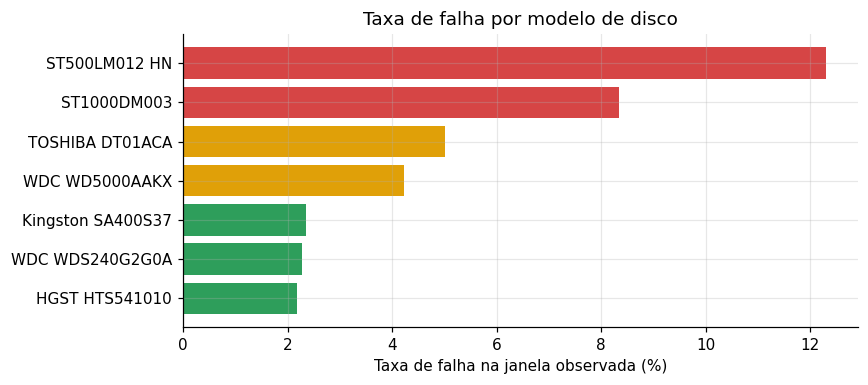

In [4]:
por_modelo = (df.groupby("model")
                .agg(discos=("serial_number", "nunique"),
                     falhas=("failure", "sum"))
                .assign(taxa_pct=lambda d: d["falhas"] / d["discos"] * 100)
                .sort_values("taxa_pct", ascending=False))

display(por_modelo.round(2))

fig, ax = plt.subplots(figsize=(8, 3.6))
cores = [COR["critico"] if t > 8 else COR["atencao"] if t > 4 else COR["ok"]
         for t in por_modelo["taxa_pct"]]
ax.barh(por_modelo.index, por_modelo["taxa_pct"], color=cores)
ax.invert_yaxis()
ax.set_xlabel("Taxa de falha na janela observada (%)")
ax.set_title("Taxa de falha por modelo de disco")
fig.tight_layout()
fig.savefig(f"{FIGURAS}/01_taxa_por_modelo.png", bbox_inches="tight")
plt.show()

A diferença entre famílias é grande, e os SSDs falham bem menos que os discos mecânicos. Isso é consistente com o que se observa nos dados reais da Backblaze.

**Ressalva importante:** o modelo do disco **não** será usado como variável preditora. Em um parque escolar real haveria dezenas de modelos diferentes, muitos com pouquíssimos exemplos, e o classificador tenderia a decorar "modelo X é ruim" em vez de aprender a ler os sinais de degradação. Preferimos que ele aprenda a partir do comportamento dos contadores, que vale para qualquer modelo — inclusive os que ainda não existiam quando o modelo foi treinado.

## 4. Definição do alvo

A coluna `failure` marca o dia da falha, mas prever a falha no dia em que ela ocorre não tem utilidade nenhuma — o laboratório já parou.

O alvo útil é outro: **este disco vai falhar dentro dos próximos 30 dias?** Isso dá ao técnico tempo hábil para agendar a troca.

In [5]:
df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

falhou = (df[df["failure"] == 1][["serial_number", "date"]]
          .rename(columns={"date": "data_falha"}))
df = df.merge(falhou, on="serial_number", how="left")

dias_ate_falha = (df["data_falha"] - df["date"]).dt.days
df["alvo"] = ((dias_ate_falha >= 0) &
              (dias_ate_falha <= HORIZONTE)).astype(int)

print(f"Linhas positivas: {int(df['alvo'].sum()):,} "
      f"({df['alvo'].mean() * 100:.2f}% do total)")
print(f"Antes da rotulagem eram {n_falhas:,} linhas "
      f"({n_falhas / len(df) * 100:.4f}%)")
print()
print("A janela de 30 dias multiplica os exemplos positivos e, mais importante,")
print("ensina o modelo a reconhecer a DEGRADAÇÃO, não o instante do colapso.")

Linhas positivas: 9,709 (1.66% do total)
Antes da rotulagem eram 315 linhas (0.0539%)

A janela de 30 dias multiplica os exemplos positivos e, mais importante,
ensina o modelo a reconhecer a DEGRADAÇÃO, não o instante do colapso.


## 5. Engenharia de features

Os contadores SMART são **cumulativos**: nunca diminuem. Um disco com 400 setores realocados que está assim há três anos é bem menos preocupante do que um que tinha 0 na semana passada e tem 50 hoje.

Ou seja: a **velocidade** de degradação carrega mais informação que o valor absoluto. As features `d7_*` capturam exatamente isso — quanto cada contador cresceu nos últimos 7 dias.

Essa é a decisão de modelagem mais relevante do projeto, e é também o que justifica tecnicamente a existência da bancada: a cada nova passagem de uma máquina, o sistema ganha um ponto de comparação e prevê melhor.

In [6]:
CONTADORES = ["smart_5_raw", "smart_187_raw", "smart_188_raw",
              "smart_197_raw", "smart_198_raw", "smart_199_raw"]

# --- features de contexto ---
df["capacidade_gb"] = df["capacity_bytes"] / 1e9
df["eh_ssd"] = df["model"].str.contains("Kingston|WDS|SSD", regex=True).astype(int)
df["anos_ligado"] = df["smart_9_raw"] / (24 * 365)

# --- agregado dos três sintomas de superfície ruim ---
df["setores_ruins_total"] = (df["smart_5_raw"] + df["smart_197_raw"]
                             + df["smart_198_raw"])

# --- velocidade de degradação: variação em 7 dias ---
grupos_disco = df.groupby("serial_number")
for coluna in CONTADORES:
    df[f"d7_{coluna}"] = (df[coluna] - grupos_disco[coluna].shift(7)) \
                         .fillna(0).clip(lower=0)

FEATURES = [
    "smart_5_raw", "smart_9_raw", "smart_12_raw", "smart_187_raw",
    "smart_188_raw", "smart_194_raw", "smart_197_raw", "smart_198_raw",
    "smart_199_raw",
    "capacidade_gb", "eh_ssd", "anos_ligado",
    *[f"d7_{c}" for c in CONTADORES],
    "setores_ruins_total",
]

print(f"{len(FEATURES)} features:")
for f in FEATURES:
    print(" ", f)

19 features:
  smart_5_raw
  smart_9_raw
  smart_12_raw
  smart_187_raw
  smart_188_raw
  smart_194_raw
  smart_197_raw
  smart_198_raw
  smart_199_raw
  capacidade_gb
  eh_ssd
  anos_ligado
  d7_smart_5_raw
  d7_smart_187_raw
  d7_smart_188_raw
  d7_smart_197_raw
  d7_smart_198_raw
  d7_smart_199_raw
  setores_ruins_total


**Nota sobre o `shift(7)`:** ele é aplicado dentro de `groupby("serial_number")`, de forma que a comparação nunca atravessa a fronteira entre dois discos diferentes. Sem o agrupamento, a última leitura de um disco seria comparada com a primeira do disco seguinte, produzindo lixo.

**Nota sobre o `clip(lower=0)`:** contadores SMART não diminuem. Valores negativos só apareceriam por falha de leitura, e são tratados como zero.

### 5.1 Como a degradação se parece nos dados

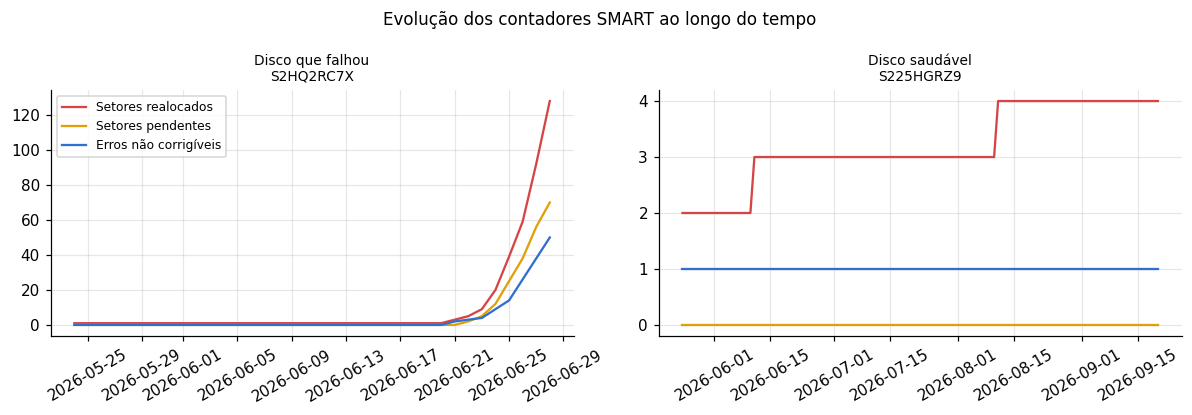

In [7]:
seriais_falhos = df[df["failure"] == 1]["serial_number"].unique()
serial_falho = seriais_falhos[3]
serial_sadio = df[~df["serial_number"].isin(seriais_falhos)]["serial_number"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, serial, titulo in [(axes[0], serial_falho, "Disco que falhou"),
                           (axes[1], serial_sadio, "Disco saudável")]:
    sub = df[df["serial_number"] == serial]
    ax.plot(sub["date"], sub["smart_5_raw"], color=COR["critico"],
            label="Setores realocados")
    ax.plot(sub["date"], sub["smart_197_raw"], color=COR["atencao"],
            label="Setores pendentes")
    ax.plot(sub["date"], sub["smart_187_raw"], color=COR["azul"],
            label="Erros não corrigíveis")
    ax.set_title(f"{titulo}\n{serial}", fontsize=9)
    ax.tick_params(axis="x", rotation=30)

axes[0].legend(fontsize=8)
fig.suptitle("Evolução dos contadores SMART ao longo do tempo", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIGURAS}/02_degradacao.png", bbox_inches="tight")
plt.show()

O contraste é o que o modelo precisa aprender: no disco que falha, os contadores saem do zero e aceleram nas semanas finais. No disco saudável, permanecem estáveis.

Repare que os dois gráficos têm escalas verticais diferentes — o disco saudável varia em uma faixa muito menor.

## 6. Separação treino/teste — e o erro que inflaria os resultados

Aqui está a decisão metodológica mais importante do notebook.

Cada disco aparece em até 120 linhas do conjunto de dados. Se a separação for feita **por linha**, o mesmo disco cai nos dois lados: o modelo vê a segunda-feira dele no treino e é avaliado na terça-feira dele no teste. Ele não aprende a reconhecer degradação — ele decora aquele disco específico.

A separação correta é **por disco** (`GroupShuffleSplit`): nenhum disco do teste foi visto no treino.

In [8]:
X = df[FEATURES]
y = df["alvo"]
grupos = df["serial_number"]

separador = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMENTE)
i_treino, i_teste = next(separador.split(X, y, grupos))

X_tr, X_te = X.iloc[i_treino], X.iloc[i_teste]
y_tr, y_te = y.iloc[i_treino], y.iloc[i_teste]

discos_tr = set(grupos.iloc[i_treino])
discos_te = set(grupos.iloc[i_teste])

print(f"Treino: {len(X_tr):,} linhas / {len(discos_tr):,} discos")
print(f"Teste : {len(X_te):,} linhas / {len(discos_te):,} discos")
print(f"Discos em comum entre treino e teste: {len(discos_tr & discos_te)}")
print()
print(f"Positivos no treino: {y_tr.mean() * 100:.2f}%")
print(f"Positivos no teste : {y_te.mean() * 100:.2f}%")

Treino: 438,173 linhas / 3,750 discos
Teste : 146,270 linhas / 1,250 discos
Discos em comum entre treino e teste: 0

Positivos no treino: 1.66%
Positivos no teste : 1.67%


### 6.1 Demonstração do vazamento

Vale medir o tamanho do engano. Abaixo, o mesmo modelo é treinado com a separação **errada**, por linha.

In [9]:
ordem = np.random.default_rng(SEMENTE).permutation(len(X))
corte = int(len(X) * 0.75)

rf_vazado = RandomForestClassifier(
    n_estimators=120, max_depth=14, min_samples_leaf=8,
    class_weight="balanced_subsample", n_jobs=-1, random_state=SEMENTE)
rf_vazado.fit(X.iloc[ordem[:corte]], y.iloc[ordem[:corte]])

pr_vazado = average_precision_score(
    y.iloc[ordem[corte:]],
    rf_vazado.predict_proba(X.iloc[ordem[corte:]])[:, 1])

print(f"PR AUC com separação POR LINHA (errada) : {pr_vazado:.4f}")
print("PR AUC com separação POR DISCO (correta) : calculado adiante")
print()
print("Guarde esse número. A diferença entre os dois é a medida exata")
print("do quanto um trabalho de manutenção preditiva pode se auto-enganar.")

PR AUC com separação POR LINHA (errada) : 0.9137
PR AUC com separação POR DISCO (correta) : calculado adiante

Guarde esse número. A diferença entre os dois é a medida exata
do quanto um trabalho de manutenção preditiva pode se auto-enganar.


## 7. Comparação de modelos

Quatro modelos, começando por uma referência trivial.

O **baseline** responde sempre "não vai falhar". Ele existe para dar sentido aos demais números: qualquer modelo que não o supere claramente não está aprendendo nada.

**Métrica escolhida: PR AUC** (*average precision*). Com 1,7% de exemplos positivos, a acurácia é enganosa e a ROC AUC é otimista demais. A curva precisão-recall é a leitura honesta em classes raras.

O parâmetro `class_weight="balanced"` faz o modelo pesar mais os exemplos raros durante o treino — sem isso, ele tende a ignorar a classe positiva por completo.

In [10]:
modelos = {
    "Baseline (sempre 'ok')": DummyClassifier(strategy="most_frequent"),

    "Regressão Logística": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced",
                           random_state=SEMENTE)),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=14, min_samples_leaf=8,
        class_weight="balanced_subsample", n_jobs=-1, random_state=SEMENTE),

    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.08, class_weight="balanced",
        random_state=SEMENTE),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    prob = modelo.predict_proba(X_te)[:, 1]
    resultados[nome] = {
        "prob": prob,
        "roc": roc_auc_score(y_te, prob) if prob.std() > 0 else 0.5,
        "pr": average_precision_score(y_te, prob),
    }
    print(f"{nome:24s}  ROC AUC {resultados[nome]['roc']:.4f}  "
          f"PR AUC {resultados[nome]['pr']:.4f}")

tabela = pd.DataFrame(
    {n: {"ROC AUC": v["roc"], "PR AUC": v["pr"]}
     for n, v in resultados.items()}).T.sort_values("PR AUC", ascending=False)
display(tabela.round(4))

Baseline (sempre 'ok')    ROC AUC 0.5000  PR AUC 0.0167


Regressão Logística       ROC AUC 0.9027  PR AUC 0.7253


Random Forest             ROC AUC 0.8981  PR AUC 0.7462


Gradient Boosting         ROC AUC 0.8911  PR AUC 0.7251


,ROC AUC,PR AUC
Random Forest,0.8981,0.7462
Regressão Logística,0.9027,0.7253
Gradient Boosting,0.8911,0.7251
Baseline (sempre 'ok'),0.5000,0.0167


**Como ler esta tabela.** O baseline terá PR AUC próximo da proporção de positivos (~0,017) e ROC AUC de 0,5 — ele é literalmente um chute.

É possível que a Regressão Logística apresente PR AUC competitivo com os modelos de árvore. Isso não significa que ela seja a melhor escolha: como veremos na seção do limiar, as probabilidades dela são mal calibradas, e no limiar padrão de 0,5 a precisão desaba. Modelos de árvore produzem probabilidades mais utilizáveis diretamente.

### 7.1 Curvas ROC e Precisão-Recall

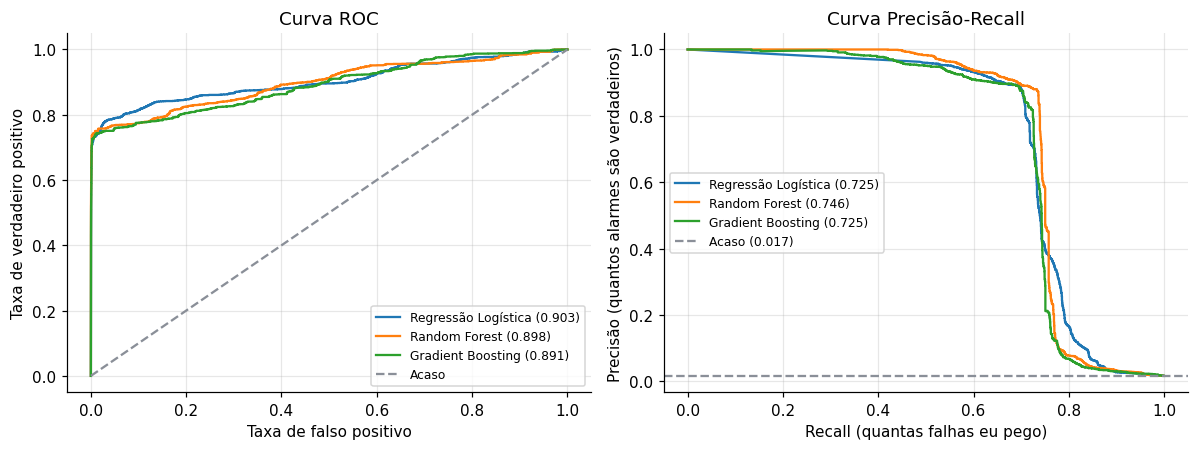

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for nome, v in resultados.items():
    if v["prob"].std() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_te, v["prob"])
    axes[0].plot(fpr, tpr, label=f"{nome} ({v['roc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_te, v["prob"])
    axes[1].plot(rec, prec, label=f"{nome} ({v['pr']:.3f})")

axes[0].plot([0, 1], [0, 1], "--", color=COR["cinza"], label="Acaso")
axes[0].set_xlabel("Taxa de falso positivo")
axes[0].set_ylabel("Taxa de verdadeiro positivo")
axes[0].set_title("Curva ROC")
axes[0].legend(fontsize=8)

axes[1].axhline(y_te.mean(), ls="--", color=COR["cinza"],
                label=f"Acaso ({y_te.mean():.3f})")
axes[1].set_xlabel("Recall (quantas falhas eu pego)")
axes[1].set_ylabel("Precisão (quantos alarmes são verdadeiros)")
axes[1].set_title("Curva Precisão-Recall")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{FIGURAS}/03_curvas.png", bbox_inches="tight")
plt.show()

A diferença entre os dois gráficos ilustra por que a ROC engana em classes raras. Na ROC, todos os modelos parecem excelentes, porque a enorme quantidade de negativos verdadeiros domina o cálculo. Na curva precisão-recall, as diferenças reais aparecem.

## 8. Matriz de confusão

Aqui os números deixam de ser abstratos e viram consequência prática.

Modelo escolhido: Random Forest

              precision    recall  f1-score   support

          ok       1.00      1.00      1.00    143827
falha em 30d       0.79      0.74      0.77      2443

    accuracy                           0.99    146270
   macro avg       0.90      0.87      0.88    146270
weighted avg       0.99      0.99      0.99    146270



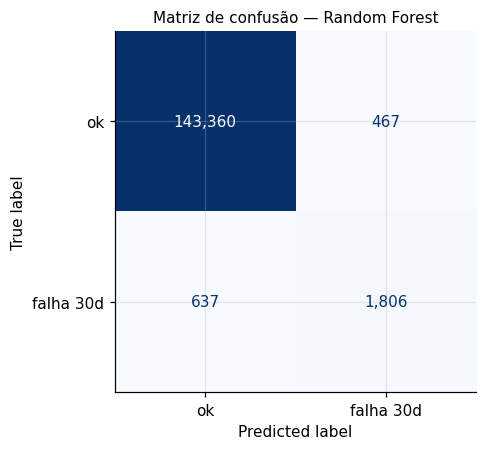


Verdadeiros positivos (1,806): falha prevista, falha ocorreu.
Falsos positivos      (467): alarme falso — técnico troca disco bom.
Falsos negativos      (637): falha não prevista — laboratório para.
Verdadeiros negativos (143,360): disco saudável corretamente ignorado.


In [12]:
melhor_nome = tabela.index[0]
prob = resultados[melhor_nome]["prob"]
pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()

print(f"Modelo escolhido: {melhor_nome}\n")
print(classification_report(y_te, pred,
                            target_names=["ok", "falha em 30d"],
                            zero_division=0))

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["ok", "falha 30d"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=",d")
ax.set_title(f"Matriz de confusão — {melhor_nome}", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIGURAS}/04_matriz.png", bbox_inches="tight")
plt.show()

print(f"\nVerdadeiros positivos ({tp:,}): falha prevista, falha ocorreu.")
print(f"Falsos positivos      ({fp:,}): alarme falso — técnico troca disco bom.")
print(f"Falsos negativos      ({fn:,}): falha não prevista — laboratório para.")
print(f"Verdadeiros negativos ({tn:,}): disco saudável corretamente ignorado.")

### O custo dos dois erros não é o mesmo

- **Falso positivo:** um disco ainda bom é trocado antes da hora. Custo: o preço de um HD e o tempo do técnico.
- **Falso negativo:** o disco morre sem aviso. Custo: laboratório parado, aulas perdidas, possível perda de dados, deslocamento emergencial do técnico.

O segundo é claramente mais caro. Isso significa que privilegiar **recall** em detrimento de precisão é a decisão correta neste domínio — e é isso que a escolha do limiar, a seguir, permite ajustar.

## 9. Escolha do limiar de decisão

O modelo devolve uma probabilidade contínua. Transformá-la em decisão exige escolher um ponto de corte, e essa escolha é um parâmetro de **operação**, não de treino.

O sistema usa três faixas, que correspondem aos LEDs da bancada:

| Faixa | Probabilidade | LED | Ação do técnico |
|---|---|---|---|
| OK | abaixo de 0,25 | Verde | Nenhuma |
| ATENÇÃO | 0,25 a 0,60 | Amarelo | Monitorar, agendar backup |
| CRÍTICO | acima de 0,60 | Vermelho | Priorizar substituição |

Limiar que maximiza F1: 0.649  (F1 = 0.7999)
Limiares usados no sistema: 0,25 (atenção) e 0,60 (crítico)


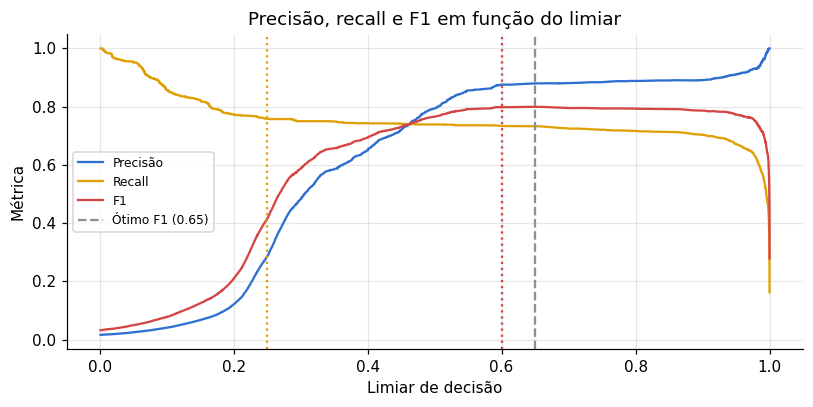

In [13]:
prec_c, rec_c, limiares = precision_recall_curve(y_te, prob)
f1 = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
limiar_otimo = limiares[int(np.argmax(f1))]

print(f"Limiar que maximiza F1: {limiar_otimo:.3f}  (F1 = {f1.max():.4f})")
print(f"Limiares usados no sistema: 0,25 (atenção) e 0,60 (crítico)")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(limiares, prec_c[:-1], color=COR["azul"], label="Precisão")
ax.plot(limiares, rec_c[:-1], color=COR["atencao"], label="Recall")
ax.plot(limiares, f1, color=COR["critico"], label="F1")
ax.axvline(limiar_otimo, ls="--", color=COR["cinza"],
           label=f"Ótimo F1 ({limiar_otimo:.2f})")
ax.axvline(0.25, ls=":", color=COR["atencao"])
ax.axvline(0.60, ls=":", color=COR["critico"])
ax.set_xlabel("Limiar de decisão")
ax.set_ylabel("Métrica")
ax.set_title("Precisão, recall e F1 em função do limiar")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIGURAS}/05_limiar.png", bbox_inches="tight")
plt.show()

**Leitura do gráfico.** Precisão e recall se movem em direções opostas. Baixar o limiar significa pegar mais falhas ao custo de mais alarmes falsos; subir faz o contrário.

Se o limiar ótimo encontrado estiver muito distante de 0,5, isso indica que as probabilidades do modelo estão **mal calibradas** — ele ordena bem os discos do pior para o melhor, mas os números absolutos que produz não correspondem a probabilidades reais. Nesse caso, ou se ajustam as faixas do sistema, ou se aplica calibração (`CalibratedClassifierCV`).

## 10. Importância das features

Além de medir o desempenho, é preciso verificar se o modelo aprendeu algo **plausível**. Um modelo com métricas boas mas que se apoia em variáveis sem sentido físico é um modelo que vai falhar em produção.

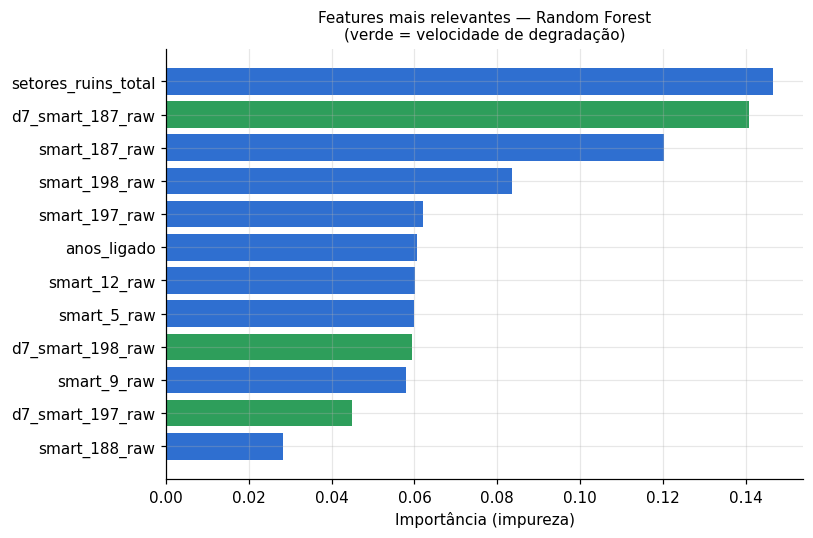

,importância
setores_ruins_total,0.1466
d7_smart_187_raw,0.1407
smart_187_raw,0.1202
smart_198_raw,0.0835
smart_197_raw,0.0620
anos_ligado,0.0605
smart_12_raw,0.0601
smart_5_raw,0.0600


In [14]:
modelo_escolhido = modelos[melhor_nome]

if hasattr(modelo_escolhido, "feature_importances_"):
    importancia = pd.Series(modelo_escolhido.feature_importances_,
                            index=FEATURES).sort_values()
    titulo_imp = "Importância (impureza)"
else:
    from sklearn.inspection import permutation_importance
    amostra = min(20000, len(X_te))
    resultado_perm = permutation_importance(
        modelo_escolhido, X_te.iloc[:amostra], y_te.iloc[:amostra],
        n_repeats=3, random_state=SEMENTE, n_jobs=-1)
    importancia = pd.Series(resultado_perm.importances_mean,
                            index=FEATURES).sort_values()
    titulo_imp = "Importância (permutação)"

top = importancia.tail(12)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top.index, top.values,
        color=[COR["ok"] if f.startswith("d7_") else COR["azul"]
               for f in top.index])
ax.set_xlabel(titulo_imp)
ax.set_title(f"Features mais relevantes — {melhor_nome}\n"
             f"(verde = velocidade de degradação)", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIGURAS}/06_importancia.png", bbox_inches="tight")
plt.show()

display(importancia.sort_values(ascending=False).head(8).round(4).to_frame("importância"))

**O que verificar aqui:**

1. As features `d7_*` (verdes) devem aparecer entre as mais importantes. Isso confirma a hipótese de que a velocidade de degradação importa mais que o valor absoluto — e valida tecnicamente a proposta da bancada.
2. `setores_ruins_total`, `smart_187_raw`, `smart_197_raw` e `smart_198_raw` no topo fazem **sentido físico**: são exatamente os indicadores de superfície magnética degradando.
3. `smart_199_raw` (erros de CRC) deve ficar em posição baixa. Se aparecesse no topo, seria sinal de que o modelo aprendeu a detectar cabo solto em vez de disco ruim.

## 11. Validação cruzada por grupo

Uma única divisão treino/teste pode ter dado sorte. A validação cruzada repete o processo cinco vezes, com discos diferentes no teste a cada rodada, e mostra a **variação** do resultado.

O `GroupKFold` preserva a regra de não dividir um mesmo disco entre os lados.

*Observação: esta célula é a mais demorada do notebook. Em uma máquina comum leva alguns minutos.*

In [15]:
rng = np.random.default_rng(SEMENTE)
discos_amostra = set(rng.choice(df["serial_number"].unique(),
                                min(2000, n_discos), replace=False))
mascara = df["serial_number"].isin(discos_amostra).values

rf_cv = RandomForestClassifier(
    n_estimators=150, max_depth=14, min_samples_leaf=8,
    class_weight="balanced_subsample", n_jobs=-1, random_state=SEMENTE)

escores = cross_val_score(rf_cv, X[mascara], y[mascara],
                          groups=grupos[mascara],
                          cv=GroupKFold(n_splits=5),
                          scoring="average_precision")

print("PR AUC por rodada:", np.round(escores, 4))
print(f"Média: {escores.mean():.4f}   Desvio padrão: {escores.std():.4f}")
print()
print("Um desvio padrão pequeno indica que o resultado é estável e não")
print("depende de quais discos caíram no conjunto de teste.")

PR AUC por rodada: [0.7056 0.7749 0.7263 0.7126 0.7731]
Média: 0.7385   Desvio padrão: 0.0297

Um desvio padrão pequeno indica que o resultado é estável e não
depende de quais discos caíram no conjunto de teste.


## 12. Tradução para impacto operacional

Métricas estatísticas não convencem um gestor. O que convence é o que muda na rotina da escola.

In [16]:
discos_teste = df.iloc[i_teste].groupby("serial_number")["alvo"].max()
n_discos_teste = len(discos_teste)
n_falhariam = int(discos_teste.sum())

precisao = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

print(f"Cenário: {n_discos_teste:,} computadores avaliados na bancada")
print(f"Destes, {n_falhariam} tinham disco prestes a falhar\n")
print(f"Com o sistema:")
print(f"  - {recall * 100:.0f}% das falhas seriam antecipadas em até 30 dias")
print(f"  - {precisao * 100:.0f}% dos alertas emitidos seriam verdadeiros\n")
print(f"Sem o sistema (situação atual da rede escolar):")
print(f"  - 0% de antecipação. Toda falha é descoberta quando o")
print(f"    computador para de ligar, com o laboratório em uso.")

Cenário: 1,250 computadores avaliados na bancada
Destes, 79 tinham disco prestes a falhar

Com o sistema:
  - 74% das falhas seriam antecipadas em até 30 dias
  - 79% dos alertas emitidos seriam verdadeiros

Sem o sistema (situação atual da rede escolar):
  - 0% de antecipação. Toda falha é descoberta quando o
    computador para de ligar, com o laboratório em uso.


## 13. Treino final e exportação do modelo

O modelo é treinado novamente com os mesmos parâmetros e salvo em disco. É este arquivo que `bancada/prever_risco.py` carrega quando um computador é conectado à bancada.

Mantemos o Random Forest como modelo de produção, ainda que outro possa apresentar PR AUC ligeiramente superior. As razões são práticas:

- produz probabilidades razoavelmente calibradas, utilizáveis nas faixas 0,25 / 0,60 sem ajuste adicional;
- é explicável — dá para mostrar à banca quais variáveis pesaram;
- treina em cerca de um minuto, o que permite retreinar sempre que novos dados chegarem.

In [17]:
modelo_final = RandomForestClassifier(
    n_estimators=300, max_depth=14, min_samples_leaf=8,
    class_weight="balanced_subsample", n_jobs=-1, random_state=SEMENTE)
modelo_final.fit(X_tr, y_tr)

prob_final = modelo_final.predict_proba(X_te)[:, 1]
roc_final = roc_auc_score(y_te, prob_final)
pr_final = average_precision_score(y_te, prob_final)

print(f"Random Forest final — ROC AUC {roc_final:.4f} | PR AUC {pr_final:.4f}")

caminho = os.path.join(MODELO, "modelo_falha_30d.joblib")
joblib.dump({"modelo": modelo_final,
             "features": FEATURES,
             "horizonte_dias": HORIZONTE},
            caminho)
print(f"Modelo salvo em {caminho}")

Random Forest final — ROC AUC 0.8981 | PR AUC 0.7462
Modelo salvo em /home/claude/pi4/ml/modelo/modelo_falha_30d.joblib


## 14. Substituição pelos dados reais da Backblaze

Esta é a etapa que falta para o projeto deixar de depender de dados simulados. **Ela precisa ser feita antes da entrega final.**

### Passo a passo

1. Acessar `backblaze.com/cloud-storage/resources/hard-drive-test-data` e baixar um trimestre (arquivo ZIP, alguns GB, contendo um CSV por dia).
2. Descompactar em uma pasta, por exemplo `data/backblaze/`.
3. Executar a célula abaixo, que consolida os CSVs diários mantendo apenas as colunas usadas.
4. Reexecutar o notebook inteiro apontando `DADOS` para o arquivo consolidado.

O código de modelagem **não muda**. É essa a vantagem de ter adotado o esquema da Backblaze desde o início.

In [18]:
# Descomente e ajuste o caminho para consolidar os dados reais.
#
# import glob
#
# COLUNAS = ["date", "serial_number", "model", "capacity_bytes", "failure",
#            "smart_5_raw", "smart_9_raw", "smart_12_raw", "smart_187_raw",
#            "smart_188_raw", "smart_194_raw", "smart_197_raw",
#            "smart_198_raw", "smart_199_raw", "smart_241_raw"]
#
# arquivos = sorted(glob.glob("data/backblaze/*.csv"))
# print(f"{len(arquivos)} arquivos diários encontrados")
#
# partes = []
# for i, arq in enumerate(arquivos):
#     parte = pd.read_csv(arq, usecols=lambda c: c in COLUNAS)
#     partes.append(parte)
#     if (i + 1) % 20 == 0:
#         print(f"  {i + 1}/{len(arquivos)}")
#
# real = pd.concat(partes, ignore_index=True)
# real = real.fillna(0)
# real.to_csv("data/backblaze_consolidado.csv.gz", index=False,
#             compression="gzip")
# print(f"{len(real):,} linhas | {real['serial_number'].nunique():,} discos")

print("Célula de consolidação — descomentar quando os dados reais estiverem baixados.")

Célula de consolidação — descomentar quando os dados reais estiverem baixados.


### O que esperar ao trocar pelos dados reais

**As métricas provavelmente vão cair.** Isso é esperado e não é um problema — é informação.

Dados reais trazem dificuldades que a simulação não reproduz:

- discos que falham **sem qualquer aviso** nos contadores SMART, por falha eletrônica ou de motor;
- centenas de modelos diferentes, muitos com pouquíssimos exemplos;
- atributos SMART preenchidos de forma inconsistente entre fabricantes;
- desbalanceamento ainda mais severo (na Backblaze, cerca de 0,1% dos discos falham por trimestre).

**Uma queda nas métricas, devidamente explicada, vale mais no relatório do que um número alto obtido em dados inventados.** A comparação entre os dois cenários é, em si, um resultado do trabalho.

## 15. Limitações e considerações finais

### Limitações reconhecidas

1. **Dados sintéticos.** Enquanto a substituição pela Backblaze não for feita, o modelo aprendeu apenas os padrões inseridos pelo gerador. Nenhuma conclusão sobre discos reais pode ser extraída.

2. **Somente discos.** O sistema prevê falha de HD e SSD. Fonte, memória e placa-mãe também falham e não são cobertos — memória exigiria testes ativos, e fonte exigiria sensores adicionais.

3. **A primeira leitura é a mais fraca.** As features `d7_*` dependem de haver uma leitura anterior. Na estreia de uma máquina na bancada elas entram zeradas, e a predição usa apenas valores absolutos. O sistema melhora conforme o parque circula.

4. **Horizonte fixo de 30 dias.** Escolhido por ser compatível com o ciclo de manutenção escolar. Outros horizontes exigiriam retreino.

5. **Sem realimentação.** O técnico não confirma no sistema se a falha prevista de fato ocorreu. Implementar esse retorno permitiria retreinar com dados do próprio parque — é a evolução natural do projeto.

### Pontos a destacar no relatório

- A separação treino/teste **por disco**, e a demonstração quantitativa do vazamento que a separação por linha produziria.
- A escolha de **PR AUC** em vez de acurácia, justificada pelo desbalanceamento.
- As features de **velocidade de degradação** (`d7_*`) como principal decisão de engenharia, e sua confirmação no gráfico de importância.
- A **assimetria de custo** entre falso positivo e falso negativo, e como o limiar operacionaliza essa escolha.
- A distinção entre um modelo que **ordena bem** e um modelo **calibrado**.

### Reprodutibilidade

Todas as etapas usam `random_state=42`. Qualquer integrante do grupo que clonar o repositório, gerar os dados e executar este notebook obterá exatamente os mesmos números.